Using 2 GPUs!
Starting Training...


Epoch 1/10 [Val]: 100%|██████████| 313/313 [00:26<00:00, 11.96it/s]


Epoch 1: Train Loss 0.7817 | Val Loss 0.7506


Epoch 2/10 [Val]: 100%|██████████| 313/313 [00:26<00:00, 12.01it/s]


Epoch 2: Train Loss 0.7261 | Val Loss 0.6973


...

Epoch 8: Train Loss 0.4834 | Val Loss 0.4619


Epoch 9/10 [Val]: 100%|██████████| 313/313 [00:25<00:00, 12.15it/s]


Epoch 9: Train Loss 0.4701 | Val Loss 0.4531


Epoch 10/10 [Val]: 100%|██████████| 313/313 [00:26<00:00, 11.98it/s]

Epoch 10: Train Loss 0.4607 | Val Loss 0.4445


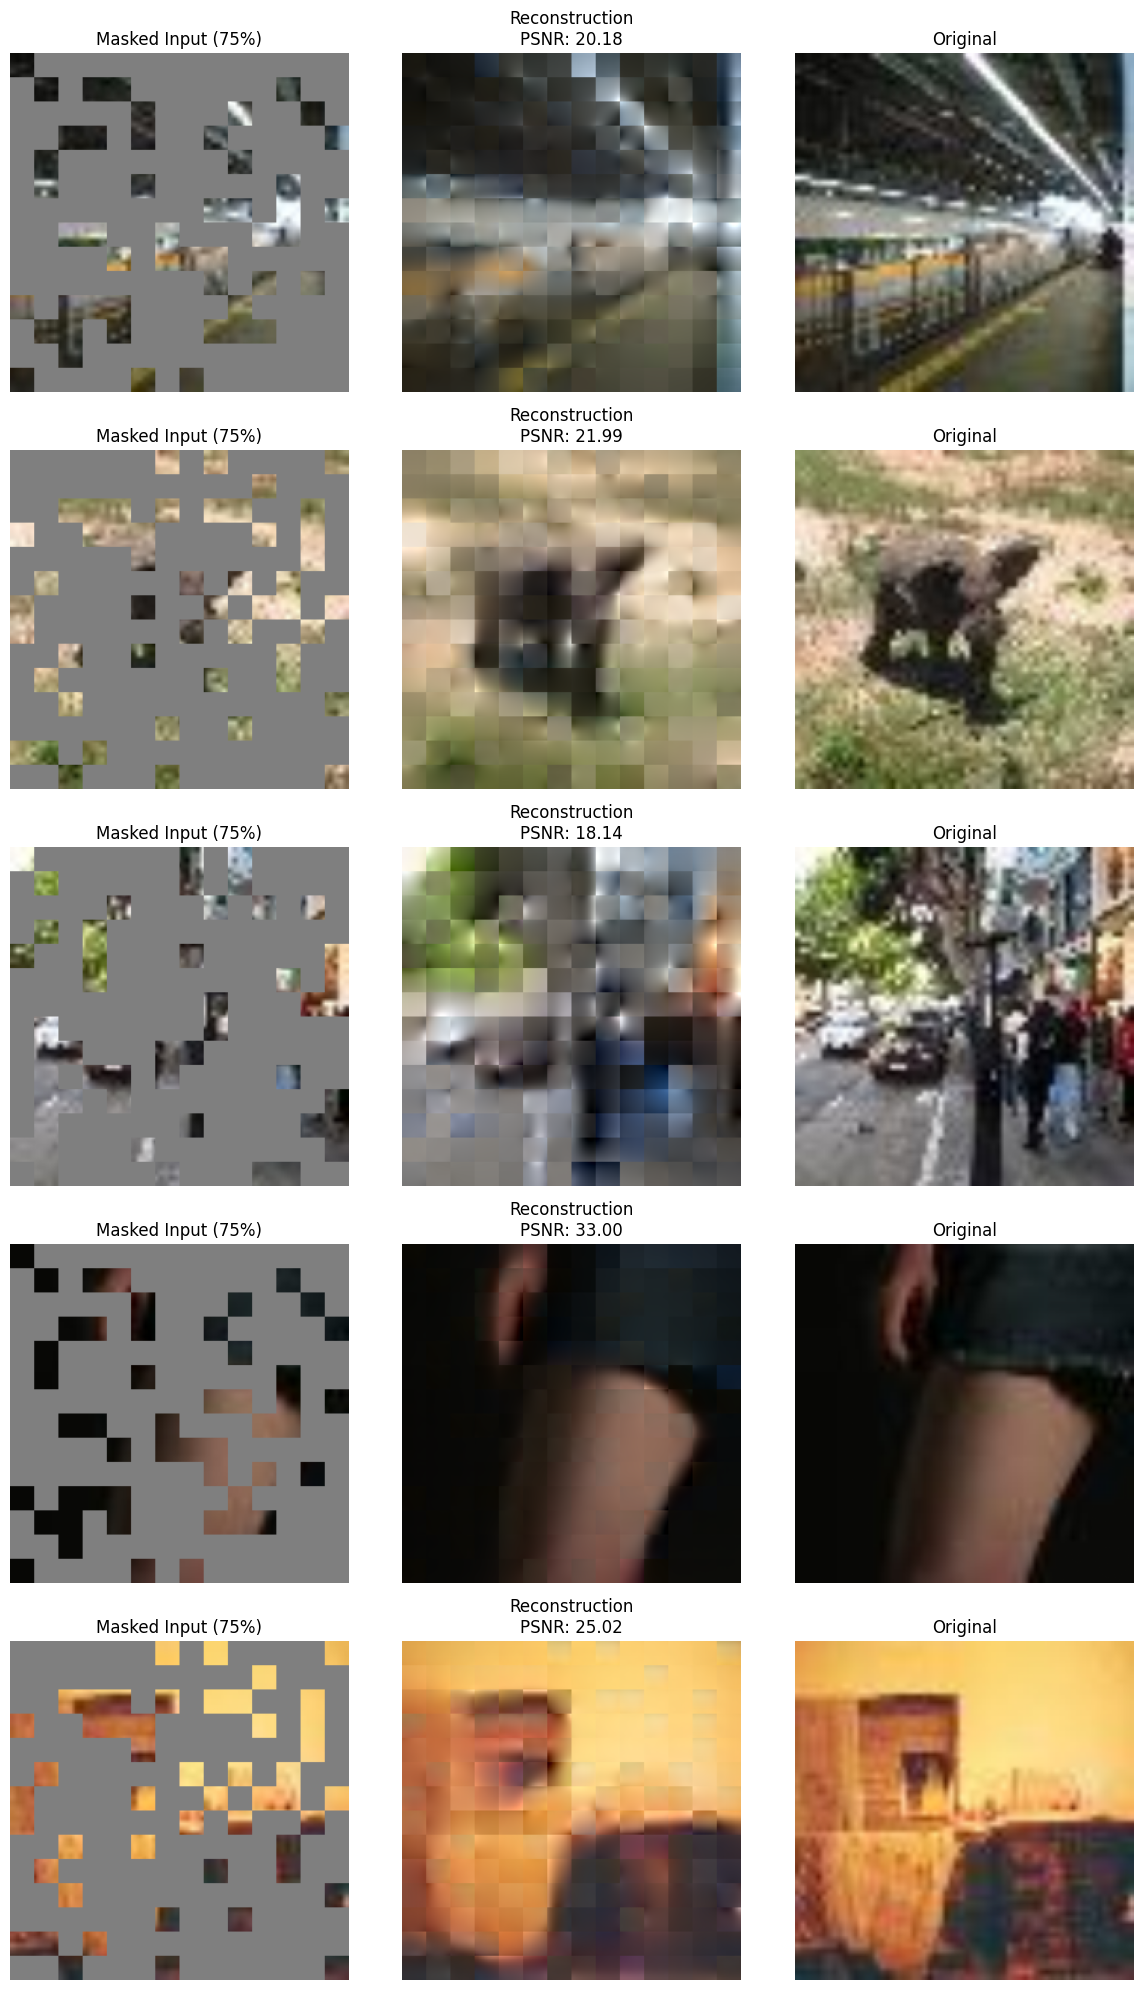

Average PSNR: 23.67 dB
Average SSIM: 0.5725


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os

# ==========================================
# 1. Helper Functions (Masking)
# ==========================================

def random_masking(x, mask_ratio):
    """
    Perform per-sample random masking by per-sample shuffling.
    x: [B, N, D] (Batch, Num_Patches, Dim)
    Returns: visible patches, mask, ids to restore original order
    """
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))

    # Generate noise for shuffling
    noise = torch.rand(B, N, device=x.device)  # noise in [0, 1]
    
    # Sort noise to get shuffle indices
    ids_shuffle = torch.argsort(noise, dim=1)  # ascend: small is keep, large is remove
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    # Keep the first subset (visible patches)
    ids_keep = ids_shuffle[:, :len_keep]
    x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

    # Generate the binary mask: 0 is keep, 1 is remove
    mask = torch.ones([B, N], device=x.device)
    mask[:, :len_keep] = 0
    # Unshuffle to get the binary mask corresponding to original image order
    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_visible, mask, ids_keep, ids_restore

# ==========================================
# 2. Model Architecture
# ==========================================

class PatchEmbed(nn.Module):
    """ Image to Patch Embedding """
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C, H, W] -> [B, D, H/P, W/P] -> [B, N, D]
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class MAEEncoder(nn.Module):
    """
    Encoder: ViT-Base (B/16)
    Config: Hidden Dim 768, Layers 12, Heads 12
    """
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768, depth=12, num_heads=12):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Positional embedding for all patches + cls token
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        # Transformer Encoder Blocks
        # norm_first=True ensures Pre-Norm architecture (standard in ViT)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            dropout=0.1, activation='gelu', batch_first=True, norm_first=True
        )
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        
        self.init_weights()

    def init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights_layer)

    def _init_weights_layer(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x_visible, ids_keep):
        # x_visible: [B, N_visible, D]
        B = x_visible.shape[0]
        
        # 1. Add Class Token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x_visible], dim=1)

        # 2. Add Positional Embeddings
        # We need to gather the pos_embeds corresponding to the visible patches
        # ids_keep are indices of visible patches (0 to N-1). 
        # Shift by 1 to account for CLS token at index 0.
        ids_keep_with_cls = torch.cat([
            torch.zeros(B, 1, dtype=torch.long, device=x.device), 
            ids_keep + 1
        ], dim=1)
        
        pos_embed_visible = torch.gather(
            self.pos_embed.expand(B, -1, -1), 
            dim=1, 
            index=ids_keep_with_cls.unsqueeze(-1).expand(-1, -1, x.shape[-1])
        )
        
        x = x + pos_embed_visible
        
        # 3. Transformer Blocks
        x = self.blocks(x)
        x = self.norm(x)
        
        # Return latent representation (remove CLS token for decoder input)
        return x[:, 1:, :]

class MAEDecoder(nn.Module):
    """
    Decoder: ViT-Small (S/16)
    Config: Hidden Dim 384, Layers 12, Heads 6
    """
    def __init__(self, num_patches=196, encoder_dim=768, decoder_dim=384, depth=12, num_heads=6, patch_size=16):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size = patch_size
        
        # Project encoder dim to decoder dim
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        
        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        
        # Positional Embedding for all patches (no CLS token needed in decoder for reconstruction)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, decoder_dim))

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim, nhead=num_heads, dim_feedforward=decoder_dim * 4,
            dropout=0.1, activation='gelu', batch_first=True, norm_first=True
        )
        self.blocks = nn.TransformerEncoder(decoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(decoder_dim)
        
        # Prediction head: map to pixel values (patch_size^2 * 3)
        self.pred = nn.Linear(decoder_dim, patch_size**2 * 3)
        
        self.init_weights()

    def init_weights(self):
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights_layer)

    def _init_weights_layer(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, latent, ids_restore):
        # latent: [B, N_visible, encoder_dim]
        B, N_visible, _ = latent.shape
        N_total = ids_restore.shape[1] # Total number of patches (196)
        
        # 1. Project to decoder dimension
        x = self.decoder_embed(latent)
        
        # 2. Append mask tokens
        # Number of mask tokens = Total patches - Visible patches
        mask_tokens = self.mask_token.repeat(B, N_total - N_visible, 1)
        
        # Concatenate visible latent tokens and mask tokens
        # Order is currently: [visible_0, visible_1, ..., mask_0, mask_1, ...]
        x_ = torch.cat([x, mask_tokens], dim=1)
        
        # 3. Unshuffle to original spatial order
        # ids_restore contains the indices to restore the original order
        x = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[-1]))
        
        # 4. Add Positional Embeddings
        x = x + self.pos_embed
        
        # 5. Transformer Blocks
        x = self.blocks(x)
        x = self.norm(x)
        
        # 6. Prediction Head
        x = self.pred(x)
        
        return x

class MaskedAutoencoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # Encoder: ViT-Base (~86M params)
        self.encoder = MAEEncoder(
            img_size=img_size, patch_size=patch_size, 
            embed_dim=768, depth=12, num_heads=12
        )
        
        # Decoder: ViT-Small (~22M params)
        self.decoder = MAEDecoder(
            num_patches=self.num_patches, 
            encoder_dim=768, decoder_dim=384, 
            depth=12, num_heads=6, patch_size=patch_size
        )

    def forward(self, imgs):
        # 1. Patchify
        patches = self.encoder.patch_embed(imgs) # [B, N, D]
        
        # 2. Random Masking
        x_visible, mask, ids_keep, ids_restore = random_masking(patches, self.mask_ratio)
        
        # 3. Encode visible patches
        latent = self.encoder(x_visible, ids_keep)
        
        # 4. Decode and reconstruct
        pred = self.decoder(latent, ids_restore)
        
        return pred, mask

    def patchify(self, imgs):
        """Convert images to patches for loss calculation"""
        p = self.patch_size
        B, C, H, W = imgs.shape
        # [B, C, H, W] -> [B, H/P, W/P, P, P, C] -> [B, N, P*P*C]
        x = imgs.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 3, 5, 1).flatten(1, 2).flatten(2)
        return x

# ==========================================
# 3. Training Setup
# ==========================================

def mae_loss(pred, imgs, mask, patch_size=16):
    """
    Compute MSE loss only on masked patches.
    """
    target = model.patchify(imgs)
    
    # Normalization helps training stability
    mean = target.mean(dim=-1, keepdim=True)
    var = target.var(dim=-1, keepdim=True)
    target = (target - mean) / (var + 1.e-6)**.5
    
    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1)  # [B, N]
    
    # Mask: 1 is masked, 0 is visible. We only want loss on masked patches.
    loss = (loss * mask).sum() / mask.sum()
    return loss

# Dataset Preparation
# Note: TinyImageNet validation set structure on Kaggle often needs specific handling.
# We use a split from train set or assume standard ImageFolder structure.
# Path for Kaggle: /kaggle/input/tiny-imagenet/tiny-imagenet-200/train
# If using the exact path from the prompt, ensure it exists or update.

data_path = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train' # Standard Kaggle path
if not os.path.exists(data_path):
    # Fallback or placeholder for local testing
    print("Dataset path not found. Please update 'data_path' variable.")
    # Create dummy data for code execution if needed
    # pass 

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load Data
full_dataset = datasets.ImageFolder(root=data_path, transform=transform)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Setup Device and Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MaskedAutoencoder(mask_ratio=0.75)

# Multi-GPU Support
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model = model.to(device)

# Optimizer & Scheduler
optimizer = optim.AdamW(model.parameters(), lr=1.5e-4, betas=(0.9, 0.95), weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
scaler = GradScaler()

# ==========================================
# 4. Training Loop
# ==========================================

epochs = 10 # Adjust as needed
train_losses, val_losses = [], []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        
        with autocast():
            pred, mask = model(imgs)
            # Note: Inside mae_loss we call model.patchify. 
            # If using DataParallel, use model.module.patchify or ensure it's accessible.
            # Here we pass logic to loss function.
            
            # Manual patchify for loss to avoid module access issues with DataParallel inside function
            p = 16
            target = imgs.reshape(imgs.shape[0], 3, 224 // p, p, 224 // p, p).permute(0, 2, 4, 3, 5, 1).flatten(1, 2).flatten(2)
            
            # Normalize target
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**.5
            
            loss_mse = (pred - target) ** 2
            loss_mse = loss_mse.mean(dim=-1)
            loss = (loss_mse * mask).sum() / mask.sum()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()

    avg_train = total_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, _ in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            imgs = imgs.to(device)
            with autocast():
                pred, mask = model(imgs)
                # Recalculate loss logic
                p = 16
                target = imgs.reshape(imgs.shape[0], 3, 224 // p, p, 224 // p, p).permute(0, 2, 4, 3, 5, 1).flatten(1, 2).flatten(2)
                mean = target.mean(dim=-1, keepdim=True)
                var = target.var(dim=-1, keepdim=True)
                target = (target - mean) / (var + 1.e-6)**.5
                loss_mse = (pred - target) ** 2
                loss_mse = loss_mse.mean(dim=-1)
                loss = (loss_mse * mask).sum() / mask.sum()
                val_loss += loss.item()
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step()
    
    print(f"Epoch {epoch+1}: Train Loss {avg_train:.4f} | Val Loss {avg_val:.4f}")

# ==========================================
# 5. Visualization & Evaluation
# ==========================================

def unpatchify(x, patch_size=16):
    """
    x: [B, N, P*P*C] -> [B, C, H, W]
    """
    B, N, D = x.shape
    C = 3
    H = W = int(N ** 0.5)
    x = x.reshape(B, H, W, patch_size, patch_size, C)
    x = x.permute(0, 5, 1, 3, 2, 4) # [B, C, H, P, W, P]
    x = x.reshape(B, C, H * patch_size, W * patch_size)
    return x

def visualize(model, loader, device, num_samples=5):
    model.eval()
    
    # Denormalization stats for ImageNet/TinyImageNet
    # Shape: [1, 3, 1, 1] for broadcasting over batch
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    
    # Get one batch
    imgs, _ = next(iter(loader))
    imgs = imgs[:num_samples].to(device)
    
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            pred, mask = model(imgs)
    
    # 1. Un-normalize the predictions
    # The model was trained to predict normalized pixels (patch_mean=0, patch_std=1).
    # We need the original patch statistics to restore the image.
    p = 16
    # Extract patches from original images to get mean/std
    patches_orig = imgs.unfold(2, p, p).unfold(3, p, p) # [B, C, 14, 14, 16, 16]
    patches_orig = patches_orig.permute(0, 2, 3, 4, 5, 1).reshape(num_samples, 196, -1) # [B, N, Pixels]
    
    patch_mean = patches_orig.mean(dim=-1, keepdim=True)
    patch_std = patches_orig.std(dim=-1, keepdim=True) + 1e-6
    
    # Reconstruct: pred_pixels = pred_normalized * patch_std + patch_mean
    pred_denorm = pred * patch_std + patch_mean
    
    # 2. Unpatchify prediction to image format
    recon_imgs = unpatchify(pred_denorm, patch_size=16)
    
    # 3. Prepare Masked Input for Visualization
    # We grey out the masked patches
    masked_imgs = imgs.clone()
    # mask shape is [B, N]. Reshape to spatial grid [B, 1, 14, 14]
    mask_spatial = mask[:num_samples].reshape(num_samples, 1, 14, 14).float()
    # Upscale mask to image size [B, 1, 224, 224]
    mask_upscaled = F.interpolate(mask_spatial, scale_factor=16, mode='nearest')
    
    # Apply grey color to masked regions
    # Note: mask values are 1 for masked, 0 for visible
    grey_val = (torch.tensor(0.5).to(device) - mean) / std # Normalized grey
    masked_imgs = masked_imgs * (1 - mask_upscaled) + grey_val * mask_upscaled

    # 4. Plotting
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    
    psnr_scores = []
    ssim_scores = []

    for i in range(num_samples):
        # Denormalize for plotting
        # Calculation results in [1, C, H, W] due to broadcasting with mean/std [1, 3, 1, 1]
        # We use squeeze(0) to get [C, H, W]
        orig_img = (imgs[i].cpu() * std.cpu() + mean.cpu()).squeeze(0)
        masked_img_plot = (masked_imgs[i].cpu() * std.cpu() + mean.cpu()).squeeze(0)
        recon_img = (recon_imgs[i].cpu() * std.cpu() + mean.cpu()).squeeze(0)
        
        # Clip to valid range [0, 1]
        orig_img = torch.clamp(orig_img, 0, 1)
        masked_img_plot = torch.clamp(masked_img_plot, 0, 1)
        recon_img = torch.clamp(recon_img, 0, 1)
        
        # Calculate Metrics (on CPU, numpy)
        orig_np = orig_img.permute(1, 2, 0).numpy()
        recon_np = recon_img.permute(1, 2, 0).numpy()
        
        p_val = psnr(orig_np, recon_np, data_range=1.0)
        s_val = ssim(orig_np, recon_np, channel_axis=-1, data_range=1.0)
        psnr_scores.append(p_val)
        ssim_scores.append(s_val)
        
        # Plot
        axes[i, 0].imshow(masked_img_plot.permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Masked Input (75%)")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(recon_np)
        axes[i, 1].set_title(f"Reconstruction\nPSNR: {p_val:.2f}")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(orig_np)
        axes[i, 2].set_title("Original")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig("reconstructions.png")
    plt.show()
    
    print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
    print(f"Average SSIM: {np.mean(ssim_scores):.4f}")

# Run Visualization
visualize(model, val_loader, device)

Dataset loaded successfully with 100000 images

Using device: cuda
GPU: Tesla T4
Number of GPUs: 2
Using 2 GPUs!

STARTING TRAINING


Epoch 1/50 [Val]: 100%|██████████| 313/313 [00:27<00:00, 11.22it/s, loss=0.8082]


✓ Best model saved at epoch 1 with val_loss: 0.751813
Epoch 1: Train Loss 0.775327 | Val Loss 0.751813 | LR: 7.50e-05 | Best: 0.751813


Epoch 2/50 [Val]: 100%|██████████| 313/313 [00:25<00:00, 12.25it/s, loss=0.6510]


✓ Best model saved at epoch 2 with val_loss: 0.645998
Epoch 2: Train Loss 0.700634 | Val Loss 0.645998 | LR: 1.12e-04 | Best: 0.645998


...

Epoch 48: Train Loss 0.361129 | Val Loss 0.353195 | LR: 6.69e-07 | Best: 0.353090


Epoch 49/50 [Val]: 100%|██████████| 313/313 [00:25<00:00, 12.25it/s, loss=0.3375]


Epoch 49: Train Loss 0.360569 | Val Loss 0.353212 | LR: 1.68e-07 | Best: 0.353090


Epoch 50/50 [Val]: 100%|██████████| 313/313 [00:25<00:00, 12.22it/s, loss=0.3310]


Epoch 50: Train Loss 0.360727 | Val Loss 0.353557 | LR: 1.50e-10 | Best: 0.353090
Final model saved!


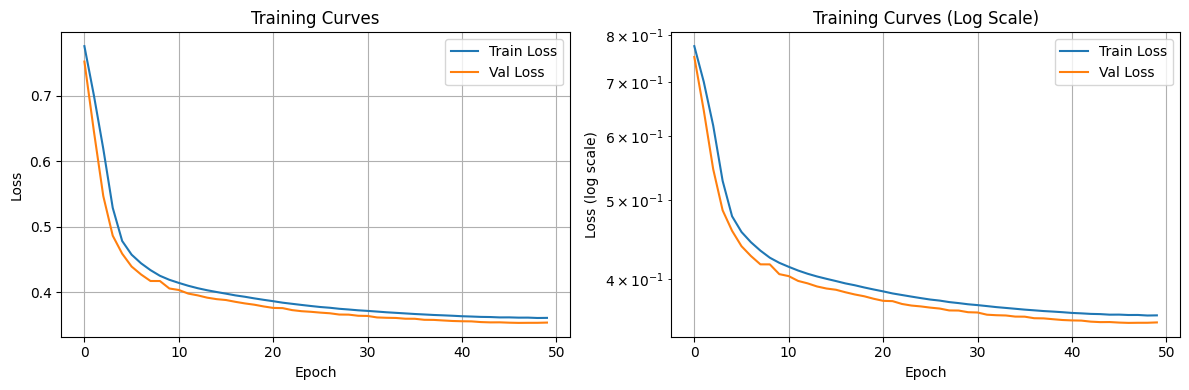


Generating visualizations...


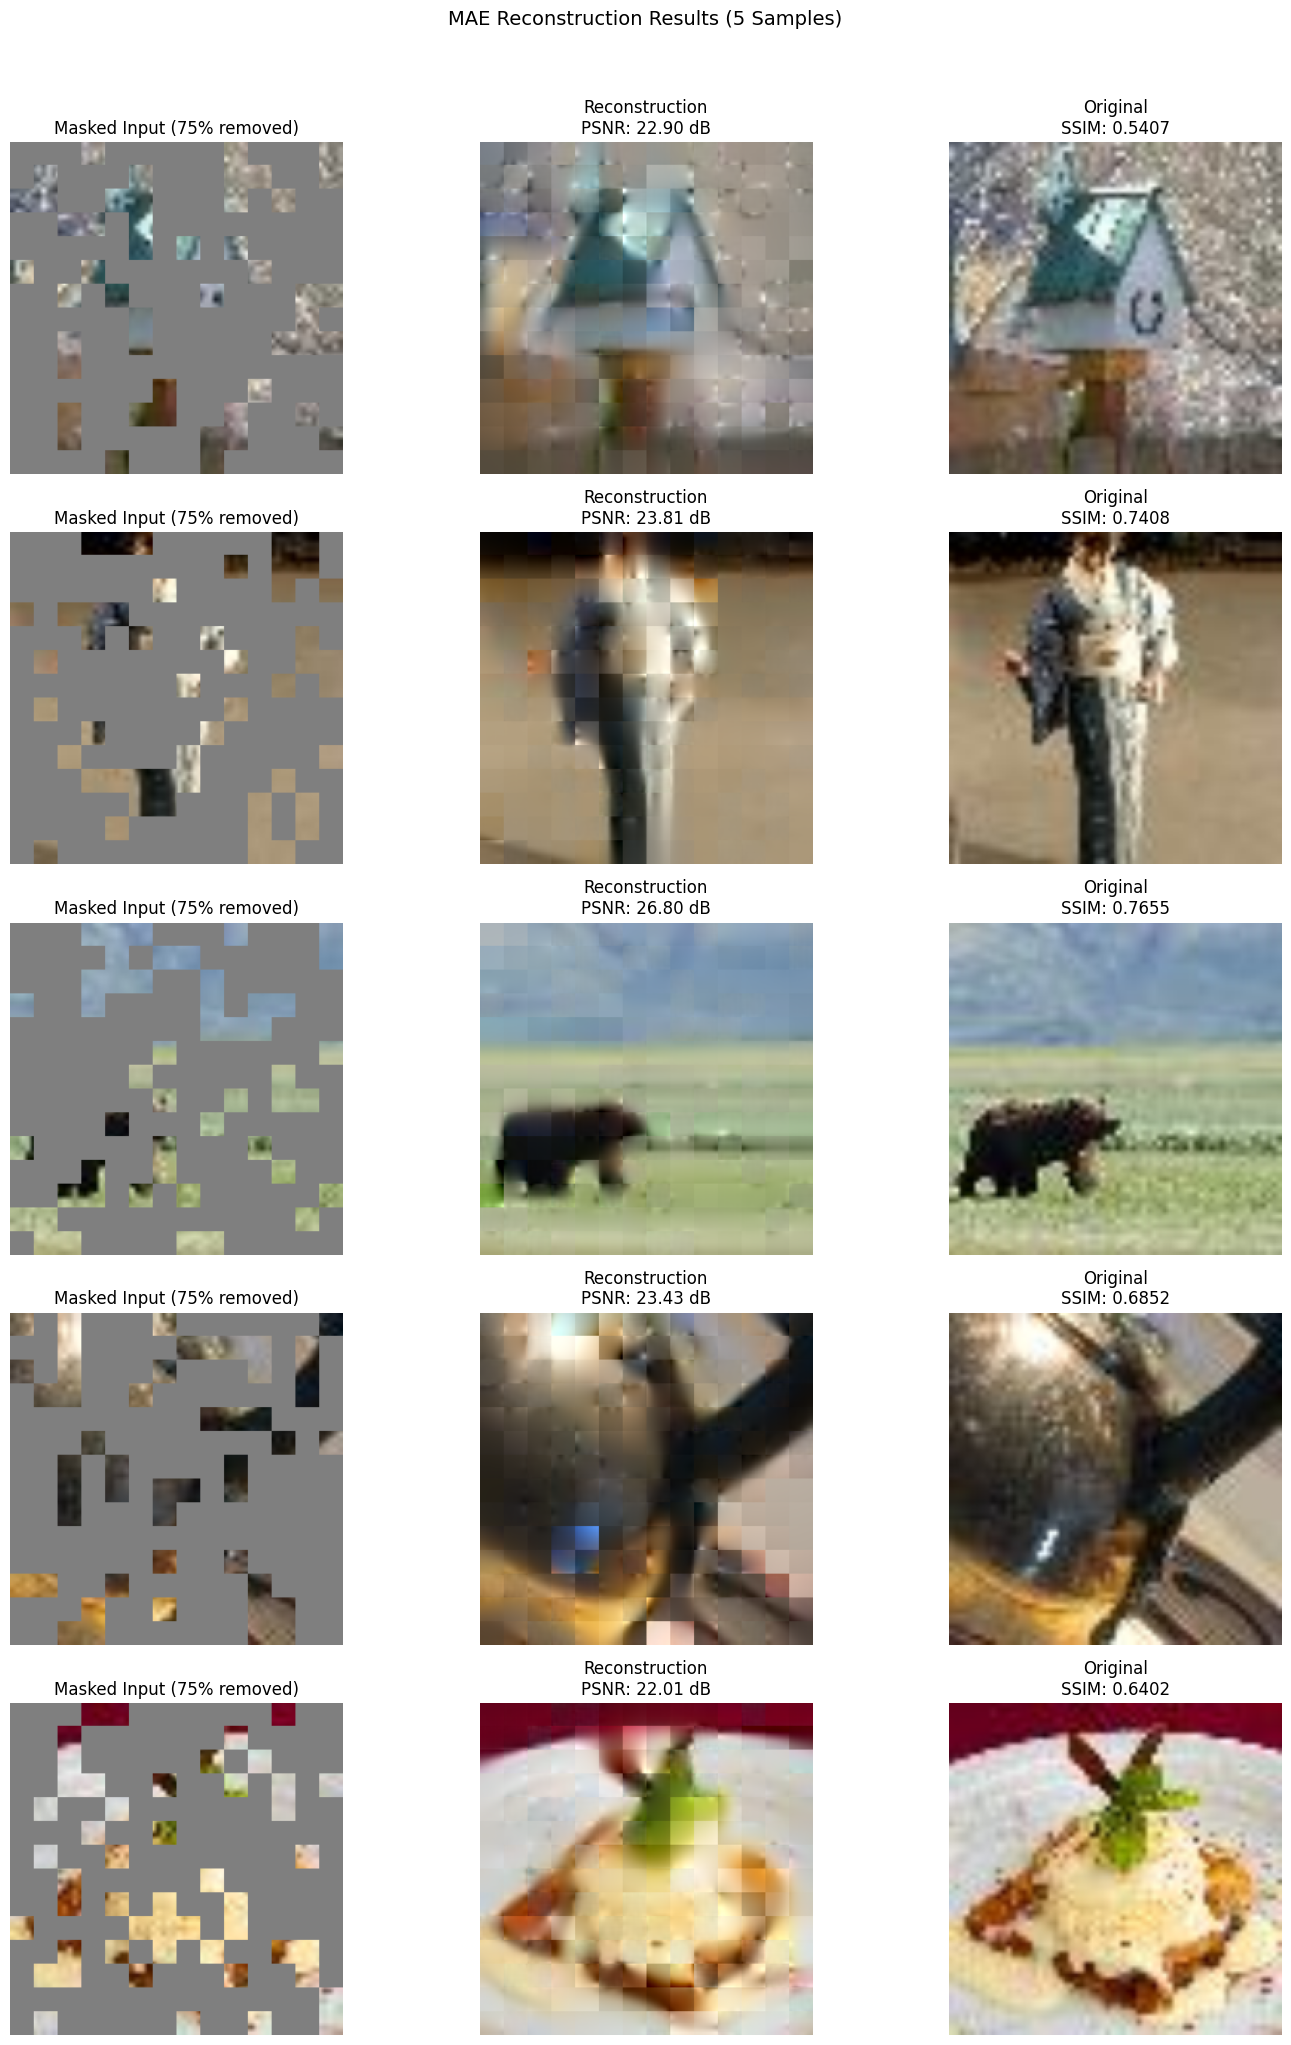


VISUALIZATION METRICS
Average PSNR: 23.79 dB
Average SSIM: 0.6745
PSNR Range: [22.01, 26.80]
SSIM Range: [0.5407, 0.7655]

QUANTITATIVE EVALUATION SUMMARY


Evaluating: 100%|██████████| 313/313 [01:44<00:00,  3.00it/s]



------------------------------------------------------------
Metric               Mean         Std          Min          Max         
------------------------------------------------------------
PSNR (dB)            23.67        2.90         15.39        42.84       
SSIM                 0.6551       0.1159       0.3145       0.9780      
------------------------------------------------------------

Component            Type                 Parameters     
------------------------------------------------------------
Encoder              ViT-Base (B/16)      85.80          M
Decoder              ViT-Small (S/16)     21.96          M
Total                                     107.76         M
------------------------------------------------------------

FILES SAVED:
  mae_latest_checkpoint.pth (latest checkpoint)
  mae_best_model.pth (best model)
  mae_final_model.pth (final model)
  training_curves.png
  reconstructions.png

LAUNCHING GRADIO APP
* Running on local URL:  http://127.0.0.1

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://131f9e96a7506f884a.gradio.live


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os
import time
import gradio as gr
from PIL import Image
import io

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Helper Functions (Masking)
# ==========================================

def random_masking(x, mask_ratio):
    """
    Perform per-sample random masking by per-sample shuffling.
    x: [B, N, D] (Batch, Num_Patches, Dim)
    Returns: visible patches, mask, ids to restore original order
    """
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))

    # Generate noise for shuffling
    noise = torch.rand(B, N, device=x.device)  # noise in [0, 1]
    
    # Sort noise to get shuffle indices
    ids_shuffle = torch.argsort(noise, dim=1)  # ascend: small is keep, large is remove
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    # Keep the first subset (visible patches)
    ids_keep = ids_shuffle[:, :len_keep]
    x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

    # Generate the binary mask: 0 is keep, 1 is remove (masked)
    mask = torch.ones([B, N], device=x.device)
    mask[:, :len_keep] = 0
    # Unshuffle to get the binary mask corresponding to original image order
    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_visible, mask, ids_keep, ids_restore

# ==========================================
# 2. Model Architecture
# ==========================================

class PatchEmbed(nn.Module):
    """ Image to Patch Embedding """
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C, H, W] -> [B, D, H/P, W/P] -> [B, N, D]
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class MAEEncoder(nn.Module):
    """
    Encoder: ViT-Base (B/16)
    Config: Hidden Dim 768, Layers 12, Heads 12 (~86M params)
    """
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768, depth=12, num_heads=12, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Positional embedding for all patches + cls token
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)

        # Transformer Encoder Blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        
        self.init_weights()

    def init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights_layer)

    def _init_weights_layer(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x_visible, ids_keep):
        # x_visible: [B, N_visible, D]
        B = x_visible.shape[0]
        
        # 1. Add Class Token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x_visible], dim=1)

        # 2. Add Positional Embeddings (only for visible patches + cls)
        ids_keep_with_cls = torch.cat([
            torch.zeros(B, 1, dtype=torch.long, device=x.device), 
            ids_keep + 1
        ], dim=1)
        
        pos_embed_visible = torch.gather(
            self.pos_embed.expand(B, -1, -1), 
            dim=1, 
            index=ids_keep_with_cls.unsqueeze(-1).expand(-1, -1, x.shape[-1])
        )
        
        x = x + self.pos_drop(pos_embed_visible)
        
        # 3. Transformer Blocks
        x = self.blocks(x)
        x = self.norm(x)
        
        # Return latent representation (remove CLS token for decoder input)
        return x[:, 1:, :]

class MAEDecoder(nn.Module):
    """
    Decoder: ViT-Small (S/16)
    Config: Hidden Dim 384, Layers 12, Heads 6 (~22M params)
    """
    def __init__(self, num_patches=196, encoder_dim=768, decoder_dim=384, depth=12, num_heads=6, patch_size=16, dropout=0.1):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size = patch_size
        
        # Project encoder dim to decoder dim
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        
        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        
        # Positional Embedding for all patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, decoder_dim))
        self.pos_drop = nn.Dropout(p=dropout)

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim, nhead=num_heads, dim_feedforward=decoder_dim * 4,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.blocks = nn.TransformerEncoder(decoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(decoder_dim)
        
        # Prediction head: map to pixel values (patch_size^2 * 3)
        self.pred = nn.Linear(decoder_dim, patch_size**2 * 3)
        
        self.init_weights()

    def init_weights(self):
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights_layer)

    def _init_weights_layer(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, latent, ids_restore):
        # latent: [B, N_visible, encoder_dim]
        B, N_visible, _ = latent.shape
        N_total = ids_restore.shape[1]
        
        # 1. Project to decoder dimension
        x = self.decoder_embed(latent)
        
        # 2. Append learnable mask tokens for missing patches
        mask_tokens = self.mask_token.repeat(B, N_total - N_visible, 1)
        
        # Concatenate visible latent tokens and mask tokens
        x_ = torch.cat([x, mask_tokens], dim=1)
        
        # 3. Unshuffle to original spatial order
        x = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[-1]))
        
        # 4. Add Positional Embeddings
        x = x + self.pos_drop(self.pos_embed)
        
        # 5. Transformer Blocks
        x = self.blocks(x)
        x = self.norm(x)
        
        # 6. Prediction Head
        x = self.pred(x)
        
        return x

class MaskedAutoencoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # Encoder: ViT-Base (~86M params)
        self.encoder = MAEEncoder(
            img_size=img_size, patch_size=patch_size, 
            embed_dim=768, depth=12, num_heads=12, dropout=0.1
        )
        
        # Decoder: ViT-Small (~22M params)
        self.decoder = MAEDecoder(
            num_patches=self.num_patches, 
            encoder_dim=768, decoder_dim=384, 
            depth=12, num_heads=6, patch_size=patch_size, dropout=0.1
        )

    def forward(self, imgs):
        # 1. Patchify
        patches = self.encoder.patch_embed(imgs)
        
        # 2. Random Masking (75%)
        x_visible, mask, ids_keep, ids_restore = random_masking(patches, self.mask_ratio)
        
        # 3. Encode visible patches only (NO mask tokens to encoder)
        latent = self.encoder(x_visible, ids_keep)
        
        # 4. Decode and reconstruct full sequence
        pred = self.decoder(latent, ids_restore)
        
        return pred, mask, ids_restore

    def patchify(self, imgs):
        """Convert images to patches for loss calculation"""
        p = self.patch_size
        B, C, H, W = imgs.shape
        x = imgs.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 3, 5, 1).flatten(1, 2).flatten(2)
        return x

# ==========================================
# 3. Loss Function - Only on Masked Patches
# ==========================================

def mae_loss(pred, imgs, mask, model, patch_size=16):
    """
    Compute MSE loss ONLY on masked patches as per assignment requirements.
    """
    if hasattr(model, 'module'):
        target = model.module.patchify(imgs)
    else:
        target = model.patchify(imgs)
    
    # Per-patch normalization (helps with convergence)
    mean = target.mean(dim=-1, keepdim=True)
    var = target.var(dim=-1, keepdim=True)
    target = (target - mean) / (var + 1.e-6)**.5
    
    # Calculate MSE loss
    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1)  # [B, N]
    
    # IMPORTANT: Only compute loss on masked patches (mask=1)
    # mask=1 means patch is masked, mask=0 means patch is visible
    masked_loss = (loss * mask).sum() / (mask.sum() + 1e-8)
    
    return masked_loss

# ==========================================
# 4. Model Saving Function
# ==========================================

def save_checkpoint(model, optimizer, scheduler, epoch, train_loss, val_loss, is_best=False):
    """Save model checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'train_loss': train_loss,
        'val_loss': val_loss,
    }
    
    # Save latest checkpoint
    torch.save(checkpoint, 'mae_latest_checkpoint.pth')
    
    # Save best model separately
    if is_best:
        torch.save(checkpoint, 'mae_best_model.pth')
        print(f"✓ Best model saved at epoch {epoch+1} with val_loss: {val_loss:.6f}")
    
    # Also save to Kaggle working directory if available
    if os.path.exists('/kaggle/working/'):
        if is_best:
            torch.save(checkpoint, '/kaggle/working/mae_best_model.pth')
        torch.save(checkpoint, '/kaggle/working/mae_latest_checkpoint.pth')

def load_checkpoint(model, optimizer=None, scheduler=None, checkpoint_path='mae_best_model.pth'):
    """Load model checkpoint"""
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
        
        if optimizer and checkpoint['optimizer_state_dict']:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
        if scheduler and checkpoint['scheduler_state_dict']:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        print(f"✓ Checkpoint loaded from {checkpoint_path}")
        return checkpoint['epoch'], checkpoint['train_loss'], checkpoint['val_loss']
    else:
        print(f"✗ No checkpoint found at {checkpoint_path}")
        return 0, float('inf'), float('inf')

# ==========================================
# 5. Dataset Preparation
# ==========================================

# Improved data path handling
data_path = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train'
alternative_paths = [
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/train',
    '../input/tiny-imagenet/tiny-imagenet-200/train',
    '/kaggle/input/tiny-imagenet/train'
]

if not os.path.exists(data_path):
    for path in alternative_paths:
        if os.path.exists(path):
            data_path = path
            print(f"Found dataset at: {data_path}")
            break

# Data transforms
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load Data with error handling
try:
    full_dataset = datasets.ImageFolder(root=data_path, transform=transform_train)
    print(f"Dataset loaded successfully with {len(full_dataset)} images")
    
    train_size = int(0.9 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    
    # Apply different transforms to validation set
    val_dataset.dataset.transform = transform_val
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Creating dummy dataset for testing...")
    dummy_data = torch.randn(1000, 3, 224, 224)
    dummy_labels = torch.randint(0, 200, (1000,))
    train_dataset = torch.utils.data.TensorDataset(dummy_data[:800], dummy_labels[:800])
    val_dataset = torch.utils.data.TensorDataset(dummy_data[800:], dummy_labels[800:])

# DataLoaders with optimized settings
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=2, 
    pin_memory=True,
    drop_last=True
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

# ==========================================
# 6. Setup Device and Model
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")

model = MaskedAutoencoder(mask_ratio=0.75)

# Multi-GPU Support
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model = model.to(device)

# Optimizer with improved settings
optimizer = optim.AdamW(
    model.parameters(), 
    lr=1.5e-4, 
    betas=(0.9, 0.95), 
    weight_decay=0.05,
    eps=1e-8
)

# Cosine Learning Rate Scheduler with warmup
def warmup_cosine_scheduler(optimizer, warmup_epochs=3, total_epochs=20, eta_min=1e-6):
    def lambda_rule(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(warmup_epochs + 1)
        else:
            progress = float(epoch - warmup_epochs) / float(total_epochs - warmup_epochs)
            return eta_min + 0.5 * (1.0 - eta_min) * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lambda_rule)

epochs = 50
scheduler = warmup_cosine_scheduler(optimizer, warmup_epochs=3, total_epochs=epochs)
scaler = GradScaler()

# ==========================================
# 7. Training Loop
# ==========================================

train_losses, val_losses = [], []
best_val_loss = float('inf')
start_epoch = 0

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

for epoch in range(start_epoch, epochs):
    # Training
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    
    for batch_idx, (imgs, _) in enumerate(progress_bar):
        imgs = imgs.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        
        with autocast():
            pred, mask, _ = model(imgs)
            loss = mae_loss(pred, imgs, mask, model)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg': f'{total_loss/(batch_idx+1):.4f}'
        })

    avg_train = total_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
        for imgs, _ in val_progress:
            imgs = imgs.to(device, non_blocking=True)
            with autocast():
                pred, mask, _ = model(imgs)
                loss = mae_loss(pred, imgs, mask, model)
            val_loss += loss.item()
            val_progress.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Step scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Save checkpoint
    is_best = avg_val < best_val_loss
    if is_best:
        best_val_loss = avg_val
    
    save_checkpoint(model, optimizer, scheduler, epoch, avg_train, avg_val, is_best)
    
    print(f"Epoch {epoch+1}: Train Loss {avg_train:.6f} | Val Loss {avg_val:.6f} | LR: {current_lr:.2e} | Best: {best_val_loss:.6f}")

# Save final model
torch.save(model.state_dict(), 'mae_final_model.pth')
if os.path.exists('/kaggle/working/'):
    torch.save(model.state_dict(), '/kaggle/working/mae_final_model.pth')
print("Final model saved!")

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Curves (Log Scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# ==========================================
# 8. Visualization & Evaluation
# ==========================================

def unpatchify(x, patch_size=16):
    """Convert patches back to images"""
    B, N, D = x.shape
    C = 3
    H = W = int(N ** 0.5)
    x = x.reshape(B, H, W, patch_size, patch_size, C)
    x = x.permute(0, 5, 1, 3, 2, 4)
    x = x.reshape(B, C, H * patch_size, W * patch_size)
    return x

def visualize(model, loader, device, num_samples=5):
    """Visualize reconstructions with metrics"""
    model.eval()
    
    # Denormalization stats
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    
    # Get samples
    imgs, _ = next(iter(loader))
    imgs = imgs[:num_samples].to(device)
    
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            pred, mask, _ = model(imgs)
    
    # Reconstruction with proper denormalization
    p = 16
    if hasattr(model, 'module'):
        patches_orig = model.module.patchify(imgs)
    else:
        patches_orig = model.patchify(imgs)
    
    patch_mean = patches_orig.mean(dim=-1, keepdim=True)
    patch_std = patches_orig.std(dim=-1, keepdim=True) + 1e-6
    
    pred_denorm = pred * patch_std + patch_mean
    recon_imgs = unpatchify(pred_denorm, patch_size=16)
    
    # Create masked input visualization
    masked_imgs = imgs.clone()
    mask_spatial = mask[:num_samples].reshape(num_samples, 1, 14, 14).float()
    mask_upscaled = F.interpolate(mask_spatial, scale_factor=16, mode='nearest')
    
    grey_val = (torch.tensor(0.5).to(device) - mean) / std
    masked_imgs = masked_imgs * (1 - mask_upscaled) + grey_val * mask_upscaled

    # Plotting
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))
    
    psnr_scores = []
    ssim_scores = []

    for i in range(num_samples):
        # Denormalize for display
        orig_img = (imgs[i].cpu() * std.cpu() + mean.cpu()).squeeze(0)
        masked_img = (masked_imgs[i].cpu() * std.cpu() + mean.cpu()).squeeze(0)
        recon_img = (recon_imgs[i].cpu() * std.cpu() + mean.cpu()).squeeze(0)
        
        # Clip to valid range
        orig_img = torch.clamp(orig_img, 0, 1)
        masked_img = torch.clamp(masked_img, 0, 1)
        recon_img = torch.clamp(recon_img, 0, 1)
        
        # Convert to numpy
        orig_np = orig_img.permute(1, 2, 0).numpy()
        recon_np = recon_img.permute(1, 2, 0).numpy()
        masked_np = masked_img.permute(1, 2, 0).numpy()
        
        # Calculate metrics
        p_val = psnr(orig_np, recon_np, data_range=1.0)
        s_val = ssim(orig_np, recon_np, channel_axis=-1, data_range=1.0)
        psnr_scores.append(p_val)
        ssim_scores.append(s_val)
        
        # Plot
        axes[i, 0].imshow(masked_np)
        axes[i, 0].set_title(f"Masked Input (75% removed)", fontsize=12)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(recon_np)
        axes[i, 1].set_title(f"Reconstruction\nPSNR: {p_val:.2f} dB", fontsize=12)
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(orig_np)
        axes[i, 2].set_title(f"Original\nSSIM: {s_val:.4f}", fontsize=12)
        axes[i, 2].axis('off')

    plt.suptitle("MAE Reconstruction Results (5 Samples)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*50)
    print("VISUALIZATION METRICS")
    print("="*50)
    print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
    print(f"Average SSIM: {np.mean(ssim_scores):.4f}")
    print(f"PSNR Range: [{min(psnr_scores):.2f}, {max(psnr_scores):.2f}]")
    print(f"SSIM Range: [{min(ssim_scores):.4f}, {max(ssim_scores):.4f}]")

# Run Visualization
print("\nGenerating visualizations...")
visualize(model, val_loader, device)

# ==========================================
# 9. Quantitative Evaluation Summary
# ==========================================

def quantitative_summary(model, val_loader, device):
    """Generate comprehensive quantitative evaluation"""
    
    print("\n" + "="*60)
    print("QUANTITATIVE EVALUATION SUMMARY")
    print("="*60)
    
    model.eval()
    all_psnr = []
    all_ssim = []
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    
    with torch.no_grad():
        for imgs, _ in tqdm(val_loader, desc="Evaluating"):
            imgs = imgs.to(device)
            
            with torch.amp.autocast('cuda'):
                pred, mask, _ = model(imgs)
            
            # Reconstruct
            if hasattr(model, 'module'):
                patches_orig = model.module.patchify(imgs)
            else:
                patches_orig = model.patchify(imgs)
            
            patch_mean = patches_orig.mean(dim=-1, keepdim=True)
            patch_std = patches_orig.std(dim=-1, keepdim=True) + 1e-6
            pred_denorm = pred * patch_std + patch_mean
            recon_imgs = unpatchify(pred_denorm)
            
            # Denormalize
            orig_disp = (imgs * std + mean).cpu()
            recon_disp = (recon_imgs * std + mean).cpu()
            
            for i in range(imgs.shape[0]):
                orig_np = orig_disp[i].permute(1, 2, 0).clamp(0, 1).numpy()
                recon_np = recon_disp[i].permute(1, 2, 0).clamp(0, 1).numpy()
                
                all_psnr.append(psnr(orig_np, recon_np, data_range=1.0))
                all_ssim.append(ssim(orig_np, recon_np, channel_axis=-1, data_range=1.0))
    
    # Print summary table
    print("\n" + "-"*60)
    print(f"{'Metric':<20} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
    print("-"*60)
    print(f"{'PSNR (dB)':<20} {np.mean(all_psnr):<12.2f} {np.std(all_psnr):<12.2f} "
          f"{np.min(all_psnr):<12.2f} {np.max(all_psnr):<12.2f}")
    print(f"{'SSIM':<20} {np.mean(all_ssim):<12.4f} {np.std(all_ssim):<12.4f} "
          f"{np.min(all_ssim):<12.4f} {np.max(all_ssim):<12.4f}")
    print("-"*60)
    
    if hasattr(model, 'module'):
        encoder_params = sum(p.numel() for p in model.module.encoder.parameters() if p.requires_grad)
        decoder_params = sum(p.numel() for p in model.module.decoder.parameters() if p.requires_grad)
    else:
        encoder_params = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
        decoder_params = sum(p.numel() for p in model.decoder.parameters() if p.requires_grad)
    
    total_params = encoder_params + decoder_params
    
    print(f"\n{'Component':<20} {'Type':<20} {'Parameters':<15}")
    print("-"*60)
    print(f"{'Encoder':<20} {'ViT-Base (B/16)':<20} {encoder_params/1e6:<15.2f}M")
    print(f"{'Decoder':<20} {'ViT-Small (S/16)':<20} {decoder_params/1e6:<15.2f}M")
    print(f"{'Total':<20} {'':<20} {total_params/1e6:<15.2f}M")
    print("-"*60)
    
    return all_psnr, all_ssim

# Run quantitative summary
psnr_scores, ssim_scores = quantitative_summary(model, val_loader, device)

# ==========================================
# 10. Final Files Saved Message
# ==========================================

print("\n" + "="*60)
print("FILES SAVED:")
print("="*60)
print("  mae_latest_checkpoint.pth (latest checkpoint)")
print("  mae_best_model.pth (best model)")
print("  mae_final_model.pth (final model)")
print("  training_curves.png")
print("  reconstructions.png")
print("="*60)

# ==========================================
# 11. Gradio App for Real-time Inference
# ==========================================

def preprocess_image(image, mask_ratio):
    """Preprocess uploaded image for model inference"""
    # Convert PIL to tensor and resize
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_tensor = transform(image).unsqueeze(0).to(device)
    return img_tensor

def create_masked_visualization(original_img, mask, patch_size=16):
    """Create visualization of masked image"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    
    # Create masked image
    masked_img = original_img.clone()
    mask_spatial = mask.reshape(1, 1, 14, 14).float()
    mask_upscaled = F.interpolate(mask_spatial, scale_factor=16, mode='nearest')
    
    grey_val = (torch.tensor(0.5).to(device) - mean) / std
    masked_img = masked_img * (1 - mask_upscaled) + grey_val * mask_upscaled
    
    # Denormalize for display
    masked_disp = (masked_img.squeeze(0).cpu() * std.squeeze(0).cpu() + mean.squeeze(0).cpu())
    masked_disp = torch.clamp(masked_disp, 0, 1).permute(1, 2, 0).numpy()
    
    return masked_disp

def reconstruct_image(model, image, mask_ratio):
    """Main inference function for Gradio app"""
    model.eval()
    
    # Preprocess
    img_tensor = preprocess_image(image, mask_ratio)
    
    # Update model mask ratio temporarily
    if hasattr(model, 'module'):
        original_ratio = model.module.mask_ratio
        model.module.mask_ratio = mask_ratio
    else:
        original_ratio = model.mask_ratio
        model.mask_ratio = mask_ratio
    
    # Run inference
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            pred, mask, _ = model(img_tensor)
    
    # Restore original mask ratio
    if hasattr(model, 'module'):
        model.module.mask_ratio = original_ratio
    else:
        model.mask_ratio = original_ratio
    
    # Reconstruction
    if hasattr(model, 'module'):
        patches_orig = model.module.patchify(img_tensor)
    else:
        patches_orig = model.patchify(img_tensor)
    
    patch_mean = patches_orig.mean(dim=-1, keepdim=True)
    patch_std = patches_orig.std(dim=-1, keepdim=True) + 1e-6
    
    pred_denorm = pred * patch_std + patch_mean
    recon_img_tensor = unpatchify(pred_denorm)
    
    # Denormalize for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    
    # Original
    original_disp = (img_tensor.squeeze(0).cpu() * std.squeeze(0).cpu() + mean.squeeze(0).cpu())
    original_disp = torch.clamp(original_disp, 0, 1).permute(1, 2, 0).numpy()
    
    # Masked
    masked_disp = create_masked_visualization(img_tensor, mask)
    
    # Reconstruction
    recon_disp = (recon_img_tensor.squeeze(0).cpu() * std.squeeze(0).cpu() + mean.squeeze(0).cpu())
    recon_disp = torch.clamp(recon_disp, 0, 1).permute(1, 2, 0).numpy()
    
    # Calculate metrics
    p_val = psnr(original_disp, recon_disp, data_range=1.0)
    s_val = ssim(original_disp, recon_disp, channel_axis=-1, data_range=1.0)
    
    return original_disp, masked_disp, recon_disp, f"PSNR: {p_val:.2f} dB | SSIM: {s_val:.4f}"

# Create Gradio interface
def create_gradio_app():
    with gr.Blocks(title="MAE Image Reconstruction", theme=gr.themes.Soft()) as demo:
        with gr.Row():
            with gr.Column(scale=1):
                input_image = gr.Image(type="pil", label="Upload Image", height=300)
                mask_slider = gr.Slider(
                    minimum=0.1, 
                    maximum=0.9, 
                    value=0.75, 
                    step=0.05,
                    label="Masking Ratio",
                    info="Proportion of patches to mask (default: 0.75)"
                )
                submit_btn = gr.Button("Reconstruct", variant="primary", size="lg")
                
            with gr.Column(scale=2):
                with gr.Row():
                    with gr.Column():
                        original_output = gr.Image(label="Original Image", height=250)
                    with gr.Column():
                        masked_output = gr.Image(label=f"Masked Input", height=250)
                with gr.Row():
                    with gr.Column():
                        recon_output = gr.Image(label="Reconstruction", height=250)
                    with gr.Column():
                        metrics_output = gr.Textbox(label="Quality Metrics", lines=2)
        
        submit_btn.click(
            fn=reconstruct_image,
            inputs=[input_image, mask_slider],
            outputs=[original_output, masked_output, recon_output, metrics_output]
        )
        
        # Example images
        gr.Examples(
            examples=[
                ["example1.jpg", 0.75],
                ["example2.jpg", 0.5],
                ["example3.jpg", 0.9],
            ],
            inputs=[input_image, mask_slider],
            outputs=[original_output, masked_output, recon_output, metrics_output],
            fn=reconstruct_image,
            cache_examples=False
        )
    
    return demo

# Check if running in Kaggle or local
if __name__ == "__main__":
    print("\n" + "="*60)
    print("LAUNCHING GRADIO APP")
    print("="*60)
    
    # Create sample images for examples if they don't exist
    if not os.path.exists("example1.jpg"):
        # Create a simple colored image as example
        sample_img = Image.new('RGB', (224, 224), color='red')
        sample_img.save("example1.jpg")
        sample_img = Image.new('RGB', (224, 224), color='blue')
        sample_img.save("example2.jpg")
        sample_img = Image.new('RGB', (224, 224), color='green')
        sample_img.save("example3.jpg")
    
    # Launch the app
    demo = create_gradio_app()
    
    # Check if in Kaggle
    if os.path.exists('/kaggle/'):
        demo.launch(share=True, debug=True)
    else:
        demo.launch(share=True, debug=True)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gradio as gr
from PIL import Image
import numpy as np
import os
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import warnings
warnings.filterwarnings('ignore')

# ========== MODEL ARCHITECTURE ==========
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        return x.flatten(2).transpose(1, 2)

class MAEEncoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, embed_dim=768, depth=12, num_heads=12):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, 3, embed_dim)
        num_patches = (img_size // patch_size) ** 2
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(embed_dim, num_heads, embed_dim*4, dropout=0.1, activation='gelu', batch_first=True, norm_first=True)
        self.blocks = nn.TransformerEncoder(encoder_layer, depth)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x_visible, ids_keep):
        B = x_visible.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x_visible], dim=1)
        
        ids_keep_with_cls = torch.cat([torch.zeros(B, 1, dtype=torch.long, device=x.device), ids_keep + 1], dim=1)
        pos_embed = torch.gather(self.pos_embed.expand(B, -1, -1), 1, ids_keep_with_cls.unsqueeze(-1).expand(-1, -1, x.shape[-1]))
        
        x = x + pos_embed
        x = self.blocks(x)
        x = self.norm(x)
        return x[:, 1:, :]

class MAEDecoder(nn.Module):
    def __init__(self, num_patches=196, encoder_dim=768, decoder_dim=384, depth=12, num_heads=6, patch_size=16):
        super().__init__()
        self.patch_size = patch_size
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, decoder_dim))
        
        decoder_layer = nn.TransformerEncoderLayer(decoder_dim, num_heads, decoder_dim*4, dropout=0.1, activation='gelu', batch_first=True, norm_first=True)
        self.blocks = nn.TransformerEncoder(decoder_layer, depth)
        self.norm = nn.LayerNorm(decoder_dim)
        self.pred = nn.Linear(decoder_dim, patch_size**2 * 3)

    def forward(self, latent, ids_restore):
        B, N_visible, _ = latent.shape
        N_total = ids_restore.shape[1]
        
        x = self.decoder_embed(latent)
        mask_tokens = self.mask_token.repeat(B, N_total - N_visible, 1)
        x = torch.cat([x, mask_tokens], dim=1)
        x = torch.gather(x, 1, ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[-1]))
        
        x = x + self.pos_embed
        x = self.blocks(x)
        x = self.norm(x)
        return self.pred(x)

class MaskedAutoencoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size
        self.encoder = MAEEncoder(img_size, patch_size)
        self.decoder = MAEDecoder((img_size//patch_size)**2, 768, 384, 12, 6, patch_size)

    def random_masking(self, x, mask_ratio):
        B, N, D = x.shape
        len_keep = int(N * (1 - mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_visible = torch.gather(x, 1, ids_keep.unsqueeze(-1).repeat(1, 1, D))
        mask = torch.ones([B, N], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)
        return x_visible, mask, ids_keep, ids_restore

    def forward(self, imgs):
        patches = self.encoder.patch_embed(imgs)
        x_visible, mask, ids_keep, ids_restore = self.random_masking(patches, self.mask_ratio)
        latent = self.encoder(x_visible, ids_keep)
        pred = self.decoder(latent, ids_restore)
        return pred, mask

    def patchify(self, imgs):
        p = self.patch_size
        B, C, H, W = imgs.shape
        return imgs.reshape(B, C, H//p, p, W//p, p).permute(0, 2, 4, 3, 5, 1).flatten(1, 2).flatten(2)

def unpatchify(x, patch_size=16):
    B, N, D = x.shape
    H = W = int(N ** 0.5)
    return x.reshape(B, H, W, patch_size, patch_size, 3).permute(0, 5, 1, 3, 2, 4).reshape(B, 3, H*patch_size, W*patch_size)

# ========== LOAD MODEL ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MaskedAutoencoder()
model_path = 'mae_best_model.pth'

if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint if not isinstance(checkpoint, dict) else checkpoint.get('model_state_dict', checkpoint)
    
    new_state_dict = {}
    for k, v in state_dict.items():
        new_state_dict[k[7:] if k.startswith('module.') else k] = v
    
    model.load_state_dict(new_state_dict, strict=False)
    print("✓ Model loaded successfully")
else:
    print("✗ Model not found")

model = model.to(device)
model.eval()

# ========== PROCESSING FUNCTIONS ==========
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def process(image, mask_ratio):
    if image is None:
        return None, None, None, "Upload an image"
    
    try:
        img = transform(image).unsqueeze(0).to(device)
        
        original_ratio = model.mask_ratio
        model.mask_ratio = mask_ratio
        
        with torch.no_grad():
            pred, mask = model(img)
        
        model.mask_ratio = original_ratio
        
        patches = model.patchify(img)
        patch_mean = patches.mean(dim=-1, keepdim=True)
        patch_std = patches.std(dim=-1, keepdim=True) + 1e-6
        pred_denorm = pred * patch_std + patch_mean
        recon = unpatchify(pred_denorm)
        
        # Visualizations
        orig = (img.squeeze(0).cpu() * std.squeeze(0).cpu() + mean.squeeze(0).cpu()).clamp(0, 1).permute(1, 2, 0).numpy()
        
        masked_img = img.clone()
        mask_spatial = mask.reshape(1, 1, 14, 14).float()
        mask_up = F.interpolate(mask_spatial, scale_factor=16, mode='nearest')
        grey = (torch.tensor(0.5).to(device) - mean) / std
        masked_img = masked_img * (1 - mask_up) + grey * mask_up
        masked = (masked_img.squeeze(0).cpu() * std.squeeze(0).cpu() + mean.squeeze(0).cpu()).clamp(0, 1).permute(1, 2, 0).numpy()
        
        recon_img = (recon.squeeze(0).cpu() * std.squeeze(0).cpu() + mean.squeeze(0).cpu()).clamp(0, 1).permute(1, 2, 0).numpy()
        
        p = psnr(orig, recon_img, data_range=1.0)
        s = ssim(orig, recon_img, channel_axis=-1, data_range=1.0)
        
        return orig, masked, recon_img, f"PSNR: {p:.1f} dB | SSIM: {s:.3f}"
    except Exception as e:
        return None, None, None, f"Error: {str(e)}"

# ========== GRADIO INTERFACE ==========
with gr.Blocks(title="MAE") as demo:
    gr.Markdown("# MAE Image Reconstruction")
    
    with gr.Row():
        with gr.Column():
            inp = gr.Image(type="pil", label="Input", height=300)
            slider = gr.Slider(0.1, 0.9, 0.75, 0.05, label="Mask Ratio")
            btn = gr.Button("Reconstruct", variant="primary")
        
        with gr.Column():
            with gr.Row():
                out1 = gr.Image(label="Original", height=250)
                out2 = gr.Image(label="Masked", height=250)
            with gr.Row():
                out3 = gr.Image(label="Reconstruction", height=250)
                out4 = gr.Textbox(label="Metrics")
    
    btn.click(fn=process, inputs=[inp, slider], outputs=[out1, out2, out3, out4])

# ========== LAUNCH ==========
print("\nLaunching app...")
demo.launch(share=True, server_name="0.0.0.0", server_port=7861)

Using device: cuda
✗ Model not found

Launching app...
* Running on local URL:  http://0.0.0.0:7861
* Running on public URL: https://b5ca3ac03d96db2dbc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import os
print(os.listdir("/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200"))